Supposedly great title

Description


In [ ]:
print("I'm working")

I'm working


In [4]:
%pip install uproot awkward matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import awkward as ak
import ROOT 

/scratch1/gjedrzej/.local/lib/python3.9/site-packages/ROOT/__init__.py:5: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(
/scratch1/gjedrzej/.local/lib/python3.9/site-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /usr/include/site/python3.9); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "


In [13]:
# FilePath = "/scratch1/gjedrzej/Lab/data/nu_tau_3_5__50_interactions.gst.root"
FilePath = "/scratch1/gjedrzej/Lab/data/nu_tau_05__80_interactions.gst.root"
file = uproot.open(FilePath)
tree = file["gst"]
print(tree.keys())


['iev', 'neu', 'fspl', 'tgt', 'Z', 'A', 'hitnuc', 'hitqrk', 'resid', 'sea', 'qel', 'mec', 'res', 'dis', 'coh', 'dfr', 'imd', 'norm', 'imdanh', 'singlek', 'nuel', 'em', 'cc', 'nc', 'charm', 'amnugamma', 'hnl', 'neut_code', 'nuance_code', 'wght', 'xs', 'ys', 'ts', 'Q2s', 'Ws', 'x', 'y', 't', 'Q2', 'W', 'EvRF', 'Ev', 'pxv', 'pyv', 'pzv', 'En', 'pxn', 'pyn', 'pzn', 'El', 'pxl', 'pyl', 'pzl', 'pl', 'cthl', 'nfp', 'nfn', 'nfpip', 'nfpim', 'nfpi0', 'nfkp', 'nfkm', 'nfk0', 'nfem', 'nfother', 'nip', 'nin', 'nipip', 'nipim', 'nipi0', 'nikp', 'nikm', 'nik0', 'niem', 'niother', 'ni', 'pdgi', 'resc', 'Ei', 'pxi', 'pyi', 'pzi', 'nf', 'pdgf', 'Ef', 'pxf', 'pyf', 'pzf', 'pf', 'cthf', 'vtxx', 'vtxy', 'vtxz', 'vtxt', 'sumKEf', 'calresp0', 'XSec', 'DXSec', 'KPS']


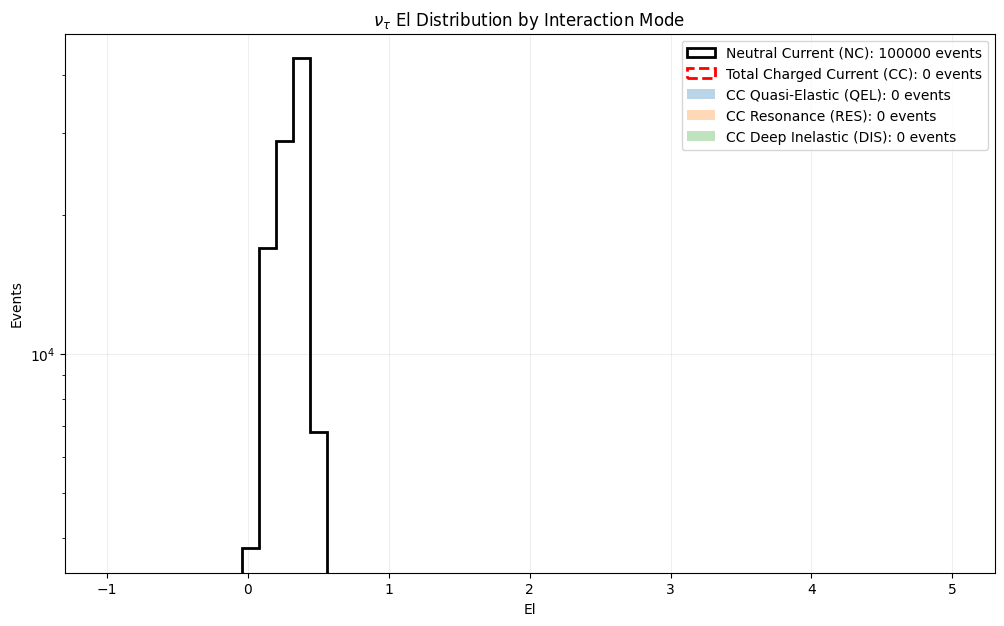

In [11]:
# Loading all relevant flags
key ='El'
range = (-1, 5)
data = tree.arrays([key, "cc", "nc", "qel", "res", "dis"])

# Define our masks
mask_nc  = (data.nc == 1)
mask_cc  = (data.cc == 1)
mask_qel = (data.cc == 1) & (data.qel == 1)
mask_res = (data.cc == 1) & (data.res == 1)
mask_dis = (data.cc == 1) & (data.dis == 1)

plt.figure(figsize=(12, 7))

# 1. Total NC (Explicitly checking nc flag)
plt.hist(data[key][mask_nc], bins=50, range=range, histtype='step', 
         linewidth=2, color='black', label=f'Neutral Current (NC): {np.sum(mask_nc)} events')


# 2. Total CC (For reference)
plt.hist(data[key][mask_cc], bins=50, range=range, histtype='step', 
         linewidth=2, color='red', linestyle='--', label=f'Total Charged Current (CC): {np.sum(mask_cc)} events')

# 3. CC Sub-modes
plt.hist(data[key][mask_qel], bins=50, range=range, alpha=0.3, 
         label=f'CC Quasi-Elastic (QEL): {np.sum(mask_qel)} events')
plt.hist(data[key][mask_res], bins=50, range=range, alpha=0.3, 
         label=f'CC Resonance (RES): {np.sum(mask_res)} events')
plt.hist(data[key][mask_dis], bins=50, range=range, alpha=0.3, 
         label=f'CC Deep Inelastic (DIS): {np.sum(mask_dis)} events')

plt.title(r"$\nu_{\tau}$ " + key + " Distribution by Interaction Mode")
plt.xlabel(key)
plt.ylabel("Events")
plt.yscale('log')
plt.legend(loc='upper right')
plt.grid(alpha=0.2)
plt.show()